# Task 1: Import the data and describe the sample

In [2]:
import pandas as pd

df = pd.read_csv('Data_PCLab1_Stock.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

n_stocks = df.columns.drop(['Date', 'sp500']).shape[0]
print(f"Number of stocks: {n_stocks}")

null_counts = df.isnull().sum()
print(f"Contains null values: {null_counts.sum() > 0}")
print(null_counts)

avg_sp500 = df['sp500'].mean()
print(f"Average market value of S&P500: {avg_sp500:.2f}")

dispersion = df.drop(columns=['Date']).std()
min_dispersion_col = dispersion.idxmin()
print(f"Minimum dispersion in dollar value: {min_dispersion_col} (std = {dispersion.min():.2f})")

max_amzn_price = df['AMZN'].max()
print(f"Maximum price for Amazon stock: {max_amzn_price:.2f}")


Number of stocks: 8
Contains null values: False
Date     0
AAPL     0
BA       0
T        0
MGM      0
AMZN     0
IBM      0
TSLA     0
GOOG     0
sp500    0
dtype: int64
Average market value of S&P500: 2218.75
Minimum dispersion in dollar value: T (std = 3.21)
Maximum price for Amazon stock: 3225.00


# Task 2: Plot the data

Matplotlib is building the font cache; this may take a moment.


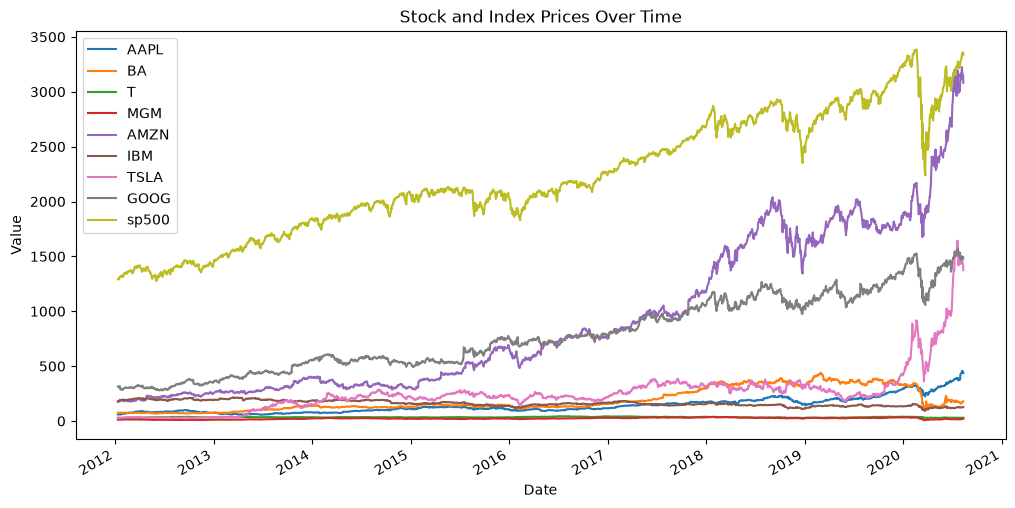

In [4]:
import matplotlib.pyplot as plt

def plot_dataframe(dataframe):
    dataframe.set_index('Date').plot(figsize=(12, 6))
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Stock and Index Prices Over Time')
    plt.legend(loc='best')
    plt.show()

plot_dataframe(df)


# Task 3: Print normalized (scaled) stock prices

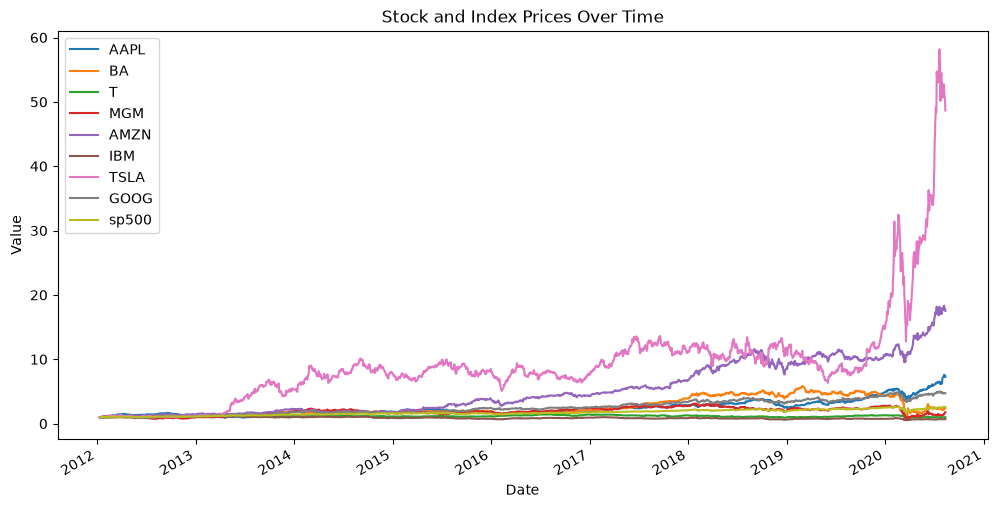

In [6]:
def normalize_prices(dataframe):
    normalized = dataframe.copy() # Not mutate original df
    price_cols = normalized.columns.drop('Date') 
    initial_prices = normalized.loc[normalized['Date'] == '2012-01-12', price_cols].iloc[0] # Pick first date row
    normalized[price_cols] = normalized[price_cols] / initial_prices
    return normalized

df_normalized = normalize_prices(df)
plot_dataframe(df_normalized)
